# 04 — Valutazione, diagnostica e inferenza

## Obiettivi didattici

1. Valutare i modelli sul **test holdout** (non visto durante il tuning).
2. Calcolare le metriche standard di regressione: RMSE, MAE, R², RMSE-log, MAPE.
3. Diagnosticare il modello con i **plot dei residui** e **predizioni vs reali**.
4. Esaminare la **feature importance** per modelli tree-based.
5. Esporre il modello tramite la funzione `predict_price()`.


In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import joblib
from pathlib import Path

from ames_pipeline.data import load_raw
from ames_pipeline.wrangling import fill_structural_missing, remove_grliv_area_outliers
from ames_pipeline.evaluation import (
    evaluate_on_holdout, regression_metrics,
    plot_predictions_vs_actual, plot_residuals,
    get_top_feature_importance, plot_feature_importance,
)
from ames_pipeline.inference import predict_price, example_input
from sklearn.model_selection import train_test_split


## Ricostruiamo lo stesso split del notebook 03

In [2]:
df = fill_structural_missing(load_raw())
df = remove_grliv_area_outliers(df)
X = df.drop(columns=['Order','PID','SalePrice'])
y = df['SalePrice']
y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_bins,
)
print(f'test set: {len(X_test)} record')


test set: 586 record


## Caricamento modelli salvati

In [3]:
models_dir = Path('../reports/models')
model_paths = {p.stem.replace('_best','').capitalize(): p
               for p in models_dir.glob('*_best.joblib')}
models = {n: joblib.load(p) for n, p in model_paths.items()}
list(models.keys())


['Xgboost', 'Ridge', 'Randomforest']

## Metriche su holdout test

| Metrica  | Significato                               | Buon valore (Ames) |
|----------|-------------------------------------------|---------------------|
| RMSE     | $ medio di errore (penalizza errori grandi) | < $25,000 |
| MAE      | $ medio di errore robusto agli outlier    | < $17,000 |
| R²       | varianza spiegata                          | > 0.90 |
| RMSE-log | scoring Kaggle                             | < 0.13 |
| MAPE     | errore % medio assoluto                    | < 10% |


In [4]:
rows = []
for name, model in models.items():
    m = evaluate_on_holdout(model, X_test, y_test)
    rows.append({'model': name, **m.as_dict()})
results_df = pd.DataFrame(rows).sort_values('rmse').set_index('model')
results_df.style.format({
    'rmse': '${:,.0f}', 'mae': '${:,.0f}',
    'r2': '{:.4f}', 'rmse_log': '{:.4f}', 'mape': '{:.2f}%',
})


,rmse,mae,r2,rmse_log,mape
model,,,,,
Xgboost,"$18,350","$11,939",0.9471,0.1055,7.19%
Ridge,"$18,509","$12,470",0.9461,0.1075,7.59%
Randomforest,"$20,825","$13,265",0.9318,0.1144,7.90%


## Diagnostica grafica del modello migliore

Cerchiamo:

- **Predizioni vs reali**: punti vicini alla bisettrice = buon fit. Sistematica sopra/sotto-stima di certe fasce di prezzo è un warning.
- **Residui (y_true - y_pred)**: distribuzione attesa ~normale, centrata sullo zero, varianza costante. Code lunghe ⇒ outlier o non linearità non catturate.


Miglior modello: Xgboost


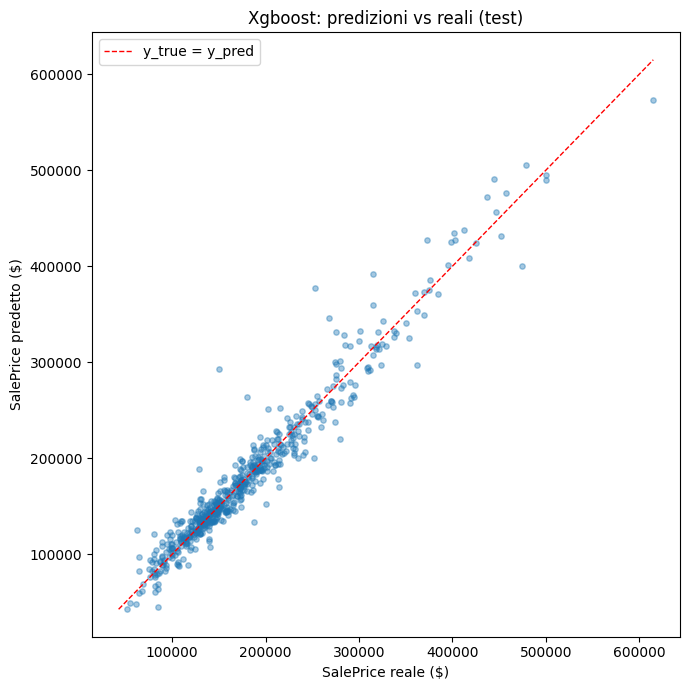

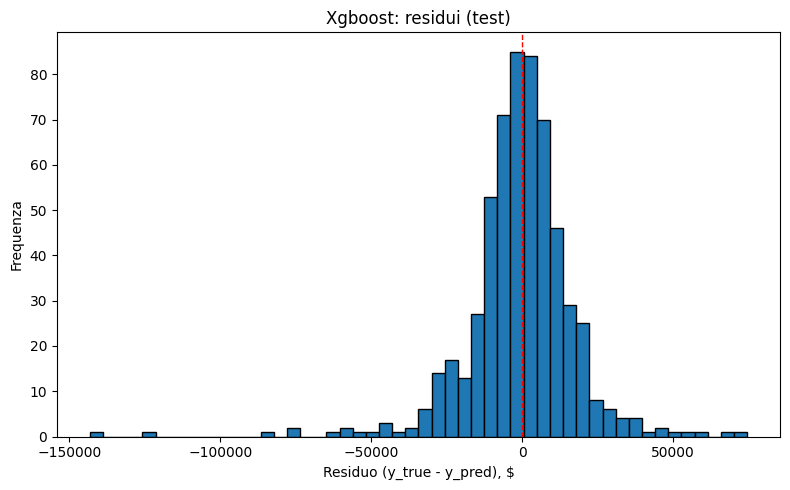

In [5]:
best_name = results_df.index[0]
print(f'Miglior modello: {best_name}')
best = models[best_name]
y_pred = best.predict(X_test)
fig1 = plot_predictions_vs_actual(y_test.values, y_pred,
    title=f'{best_name}: predizioni vs reali (test)')
plt.show()
fig2 = plot_residuals(y_test.values, y_pred,
    title=f'{best_name}: residui (test)')
plt.show()


## Feature importance (modelli tree-based)

Solo `RandomForest` e `XGBoost` espongono `feature_importances_`. Per Ridge si possono usare i coefficienti standardizzati.


=== Randomforest top-20 ===
          feature  importance
      OverallQual    0.308851
          TotalSF    0.274555
     QualityScore    0.053632
        ExterQual    0.041297
         HouseAge    0.028547
        GrLivArea    0.027514
        YearBuilt    0.025691
       GarageArea    0.020493
        TotalBath    0.017292
       GarageCars    0.014366
          LotArea    0.011700
         1stFlrSF    0.011694
      AreaPerRoom    0.009896
      TotalBsmtSF    0.009651
         BsmtQual    0.009047
      KitchenQual    0.009044
      GarageYrBlt    0.007650
YearsSinceRemodel    0.007072
       BsmtFinSF1    0.006123
     YearRemodAdd    0.005858


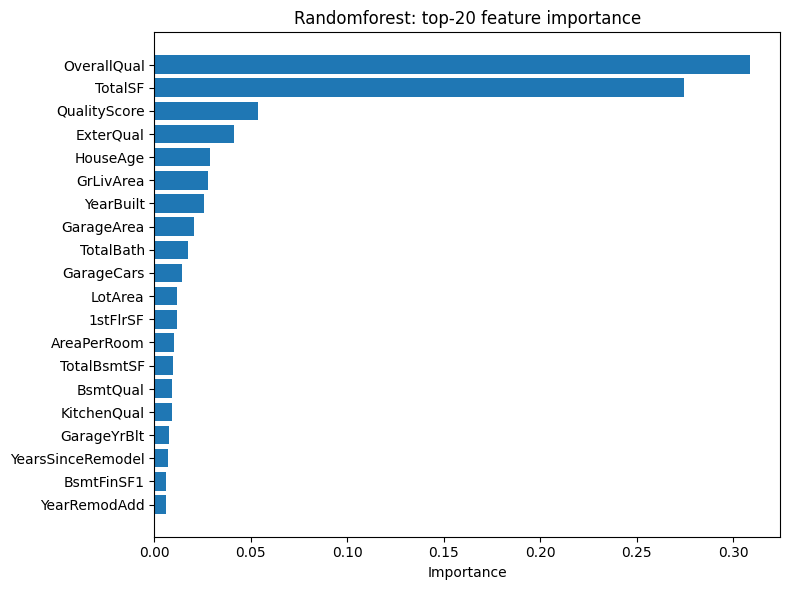


=== Xgboost top-20 ===
          feature  importance
      OverallQual    0.121938
          TotalSF    0.104460
        ExterQual    0.101001
      KitchenQual    0.048623
       GarageCars    0.046021
     CentralAir_N    0.036204
      MSZoning_RL    0.035810
        TotalBath    0.031962
     CentralAir_Y    0.028559
     QualityScore    0.027215
     KitchenAbvGr    0.023953
      MSZoning_RM    0.023839
         BsmtQual    0.023674
      FireplaceQu    0.021644
       PavedDrive    0.017034
     GarageFinish    0.016136
       Fireplaces    0.013804
     HasFireplace    0.013281
       GarageCond    0.012938
GarageType_Attchd    0.010644


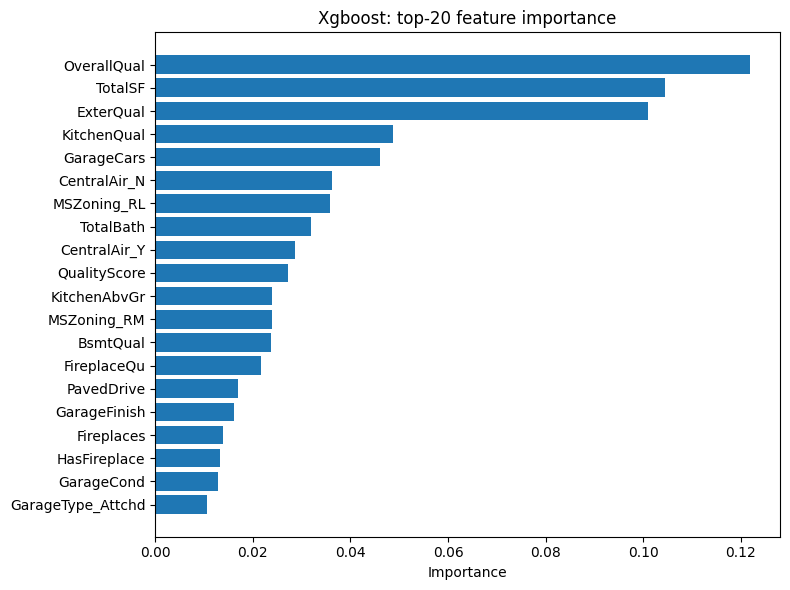

In [6]:
for name in ('Randomforest', 'Xgboost'):
    if name not in models:
        continue
    model = models[name]
    # Ricavo i nomi feature post-preprocessor
    try:
        ttr = model
        from sklearn.compose import TransformedTargetRegressor
        if isinstance(ttr, TransformedTargetRegressor):
            ttr = ttr.regressor_
        feature_names = ttr.named_steps['preprocessor'].get_feature_names_out()
    except Exception:
        feature_names = []
    df_imp = get_top_feature_importance(model, feature_names, top_n=20)
    print(f'\n=== {name} top-20 ===')
    print(df_imp.to_string(index=False))
    plot_feature_importance(df_imp, title=f'{name}: top-20 feature importance')
    plt.show()


## Inferenza: la funzione `predict_price()`

L'API è semplice: si passa un dizionario con le feature note (anche un sottoinsieme) e ritorna il prezzo predetto in dollari. Le colonne mancanti sono imputate automaticamente.

In [7]:
base = example_input()
print(f"Casa-base: ${predict_price(base):,.0f}")

luxury = {**base, 'OverallQual': 9, 'GrLivArea': 2400, '1stFlrSF': 1400,
          '2ndFlrSF': 1000, 'TotalBsmtSF': 1400, 'Neighborhood': 'NridgHt'}
print(f"Casa-lusso: ${predict_price(luxury):,.0f}")

# Solo 4 feature: tutto il resto viene imputato
minimal = {'OverallQual': 7, 'GrLivArea': 1800,
           'Neighborhood': 'CollgCr', 'YearBuilt': 2005}
print(f"Casa-minimal (4 feature): ${predict_price(minimal):,.0f}")


Casa-base: $97,986


Casa-lusso: $163,814
Casa-minimal (4 feature): $87,223


## Conclusione

Il pipeline è ora **production-ready** nel senso che:

1. È serializzato con `joblib` → re-deployable su qualsiasi macchina con le stesse versioni delle librerie (vedi `requirements.txt`).
2. La funzione `predict_price()` è l'unico punto di ingresso per l'inferenza, evitando duplicazione di logica.
3. Tutte le metriche sono in dollari, comprensibili anche per stakeholder non tecnici.

Per dettagli teorici sulle scelte fatte (perché log-target, perché Ridge vs Lasso, perché XGBoost batte RF, ...) vedi `docs/teoria/`.